# How this notebook is laid out - Tabular Q-Learning for Warehouse Navigation

1) First load required packages
2) Imlement the warehouse environment
3) Build and train (1000 epochs) for Q-Learning
4) Build and train (1000 epochs) for SARSA
5) Compare Q-Learning to SARSA and use ideal policy as baseline
6) Write three-page report (see report.pdf or report.tex in the \report folder) but answers are also in this notebook


## Introduction

This notebook studies **tabular reinforcement learning** in a small stochastic warehouse navigation problem. The environment is a $4 \times 4$ grid world in which an agent starts at the lower-left corner and must learn how to reach a goal state at $(3, 3)$ while avoiding a hazardous state at $(3, 2)$. The task is intentionally simple enough that the full state space can be represented exactly with a tabular value function, yet rich enough to highlight important reinforcement-learning ideas such as stochastic transitions, exploration, bootstrapping, and the difference between **off-policy** and **on-policy** learning.

The warehouse dynamics are **stochastic**: when the agent selects an action, the intended move is followed with probability $0.8$, while each perpendicular action occurs with probability $0.1$. This uncertainty makes the problem more realistic than a deterministic shortest-path task, because the agent must account for the possibility of slipping into undesirable states. Each non-terminal transition incurs a small living reward of $-0.04$, reaching the goal gives a reward of $+1$, and entering the hazard yields $-1$. As a result, the learned policy must trade off safety, efficiency, and long-term return.

The main purpose of the experiment is to compare **Q-learning** and **SARSA** on the same control problem. Both algorithms learn action values from sampled experience, but they differ in a fundamental way. Q-learning uses the greedy backup target $\max_a Q(s', a)$ and therefore learns toward the optimal policy regardless of the exploratory action actually taken. SARSA instead updates using the action chosen by the current $\varepsilon$-greedy policy, so it learns the value of behaving according to its current exploration strategy. This distinction is especially important near the hazard, where exploratory mistakes can be costly.

The notebook proceeds in several stages. First, it defines the warehouse environment and interaction interface. Next, it trains a Q-learning agent for 1000 episodes and extracts the learned greedy policy $\pi(s) = \arg\max_a Q(s,a)$. It then repeats the experiment with SARSA under the same training horizon so that the two methods can be compared fairly. After training, the notebook plots rolling-average reward curves for both methods and compares them to an **optimal expected return** computed with value iteration. This provides a model-based benchmark for the model-free learners.

Beyond comparing reward curves, the notebook also compares the learned policies directly against the optimal policy from value iteration. This makes it possible to identify which states are learned correctly and where the methods differ, particularly in states adjacent to the hazard. Finally, the notebook includes a **hyperparameter sensitivity study** over learning rate $\alpha$ and exploration decay rate $\rho$ to examine how quickly different configurations converge and which settings are unstable or fail to learn reliably.

Overall, this experiment is designed to show not only whether the agent learns successfully, but also **how different reinforcement-learning algorithms behave under uncertainty**. In particular, it illustrates why Q-learning often learns more aggressive goal-directed behavior, while SARSA can learn safer policies in risky regions because it accounts for the consequences of continued exploration.

In [1]:
# Verify required packages are available
import sys
import subprocess
print(f"Python version: {sys.version}")

try:
    import numpy as np
    print(f"✓ numpy {np.__version__} is available")
except ImportError as e:
    print(f"✗ numpy not available: {e}")

try:
    import pandas as pd
    print(f"✓ pandas {pd.__version__} is available")
except ImportError as e:
    print(f"✗ pandas not available: {e}")

try:
    import matplotlib.pyplot as plt
    print("✓ matplotlib is available")
except ImportError as e:
    print(f"✗ matplotlib not available: {e}")

try:
    import sklearn
    print(f"✓ scikit-learn {sklearn.__version__} is available")
except ImportError as e:
    print(f"✗ scikit-learn not available: {e}")
    print("Installing scikit-learn...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--break-system-packages", "scikit-learn"] )

try:
    import torch
except ImportError:
    print("PyTorch not found. Installing torch...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--break-system-packages", "torch"] )
    import torch

print(f"✓ PyTorch {torch.__version__} is available")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✓ PyTorch loaded on: {device}")

print("All required packages are ready!")

Python version: 3.12.13 (main, Mar  3 2026, 12:39:30) [Clang 17.0.0 (clang-1700.6.3.2)]
✓ numpy 2.4.1 is available
✓ pandas 3.0.1 is available
✓ matplotlib is available
✓ scikit-learn 1.8.0 is available
✓ PyTorch 2.11.0 is available
✓ PyTorch loaded on: cpu
All required packages are ready!


## Task 1: Implement the warehouse environment

Implement the warehouse environment. Write an environment class that takes a state and action, samples the next state from the stochastic transition model (80/10/10), and returns the reward. 
The agent interacts only through this interface—it never accesses T or R directly.

In [2]:
class WarehouseEnv:
    """4x4 warehouse grid MDP for reinforcement learning.
    The agent does NOT have access to the transition model or
    reward function. It can only observe (state, action, reward,
    next_state, done) tuples through interaction.
    States are (x, y) tuples with x in {0..3}, y in {0..3}.
    Actions: 0=North, 1=South, 2=West, 3=East.
    Transitions: 80% intended direction, 10% each perpendicular.
    """
    GRID_W = 4
    GRID_H = 4
    GOAL = (3, 3)       # +1 reward
    HAZARD = (3, 2)     # -1 reward
    TERMINALS = {(3, 3), (3, 2)}
    ACTIONS = [(0, 1), (0, -1), (-1, 0), (1, 0)]  # N, S, W, E
    ACTION_NAMES = ['N', 'S', 'W', 'E']
    N_ACTIONS = 4
    LIVING_REWARD = -0.04
    START = (0, 0)
    def __init__(self):
        self.state = self.START
    def reset(self):
        """Reset to start state and return it."""
        self.state = self.START
        return self.state
    def get_all_states(self):
        """Return all non-terminal states."""
        return [(x, y) for x in range(self.GRID_W)
                for y in range(self.GRID_H)
                if (x, y) not in self.TERMINALS]
    def step(self, action):
        """Take action, return (next_state, reward, done).
        Reward convention: r = R(s'), the reward for entering the
        next state (Section 7.1.4: Returns and Value Functions).
        """
        if self.state in self.TERMINALS:
            return self.state, 0.0, True
        # Stochastic transitions (80/10/10)
        intended = self.ACTIONS[action]
        if action in (0, 1):  # N or S
            perps = [self.ACTIONS[2], self.ACTIONS[3]]
        else:                  # W or E
            perps = [self.ACTIONS[0], self.ACTIONS[1]]
        r = np.random.random()
        if r < 0.8:
            move = intended
        elif r < 0.9:
            move = perps[0]
        else:
            move = perps[1]
        nx = max(0, min(self.GRID_W - 1, self.state[0] + move[0]))
        ny = max(0, min(self.GRID_H - 1, self.state[1] + move[1]))
        next_state = (nx, ny)
        if next_state == self.GOAL:
            reward, done = 1.0, True
        elif next_state == self.HAZARD:
            reward, done = -1.0, True
        else:
            reward, done = self.LIVING_REWARD, False
        self.state = next_state
        return next_state, reward, done

## Task 2: Implement Q-Learning with epsilon-greedy exploration.

![Task 2](images/Task2.png)

In [3]:
def epsilon_greedy(Q, state, epsilon, n_actions):
    """Select action using epsilon-greedy policy."""
    if np.random.random() < epsilon:
        return np.random.randint(n_actions)
    q_vals = [Q.get((state, a), 0.0) for a in range(n_actions)]
    return int(np.argmax(q_vals))
def q_learning(env, n_episodes=1000, alpha=0.1, gamma=0.99,
               epsilon_start=1.0, epsilon_decay=0.995,
               epsilon_min=0.01):
    """Train Q-learning on the warehouse grid.
    Returns the Q-table and per-episode rewards.
    """
    Q = {}
    epsilon = epsilon_start
    rewards = []
    for _ in range(n_episodes):
        state = env.reset()
        done = False
        total_reward = 0
        while not done:
            action = epsilon_greedy(Q, state, epsilon, env.N_ACTIONS)
            next_state, reward, done = env.step(action)
            total_reward += reward
            # Terminal states: Q(s', a') = 0 for all a'
            if done:
                target = reward
            else:
                max_q = max(Q.get((next_state, a), 0.0)
                            for a in range(env.N_ACTIONS))
                target = reward + gamma * max_q
            old_q = Q.get((state, action), 0.0)
            Q[(state, action)] = old_q + alpha * (target - old_q)
            state = next_state
        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        rewards.append(total_reward)
    return Q, rewards

In [5]:
env = WarehouseEnv()
np.random.seed(42)

Q, episode_rewards = q_learning(env, n_episodes=1000)

print(f"Training complete: {len(episode_rewards)} episodes")
print(f"Mean reward (last 100 episodes): {np.mean(episode_rewards[-100:]):.4f}")
print(f"Min reward: {min(episode_rewards):.4f}  Max reward: {max(episode_rewards):.4f}")

# Extract learned policy: pi(s) = argmax_a Q(s, a)
policy = {
    s: int(np.argmax([Q.get((s, a), 0.0) for a in range(env.N_ACTIONS)]))
    for s in env.get_all_states()
}

print("\nLearned policy (state -> action):")
for y in range(env.GRID_H - 1, -1, -1):
    row = []
    for x in range(env.GRID_W):
        s = (x, y)
        if s in env.TERMINALS:
            label = " G " if s == env.GOAL else " H "
        else:
            label = f" {env.ACTION_NAMES[policy[s]]} "
        row.append(label)
    print("|" + "|".join(row) + "|")

Training complete: 1000 episodes
Mean reward (last 100 episodes): 0.7192
Min reward: -5.7600  Max reward: 0.8000

Learned policy (state -> action):
| E | E | E | G |
| N | N | W | H |
| N | N | N | S |
| N | N | N | W |


## Summary and Observations: Q-Learning

Q-learning was implemented as an off-policy temporal-difference control algorithm with $\varepsilon$-greedy exploration, learning rate $\alpha=0.1$, discount factor $\gamma=0.99$, and an exponentially decaying exploration schedule. Over 1000 episodes, the agent learned a stable action-value table $Q(s,a)$ and a greedy policy $\pi(s)=\arg\max_a Q(s,a)$ that generally drives the robot efficiently toward the goal.

### Key observations
- Early training is noisy due to high exploration ($\varepsilon$ near 1), producing wide reward variance and occasional hazard visits.
- As $\varepsilon$ decays, returns improve and the learned policy becomes increasingly consistent and goal-directed.
- Because Q-learning uses the optimistic target $\max_a Q(s',a)$, it tends to learn more aggressive routes near risky states.
- Near the hazard at $(3,2)$, the policy may prefer shorter but higher-risk paths compared with safer on-policy alternatives.
- The learned performance trends toward the value-iteration benchmark, indicating effective convergence in this small tabular state space.

## Task 3: Implement SARSA

SARSA Implementation
On-policy SARSA (definition 7.17) uses the action actually taken at the next state, making it more conservative near hazards (comment 7.10).

In [6]:
def sarsa(env, n_episodes=1000, alpha=0.1, gamma=0.99,
          epsilon_start=1.0, epsilon_decay=0.995,
          epsilon_min=0.01):
    """Train SARSA on the warehouse grid."""
    Q = {}
    epsilon = epsilon_start
    rewards = []
    for _ in range(n_episodes):
        state = env.reset()
        action = epsilon_greedy(Q, state, epsilon, env.N_ACTIONS)
        done = False
        total_reward = 0
        while not done:
            next_state, reward, done = env.step(action)
            total_reward += reward
            if done:
                target = reward
            else:
                next_action = epsilon_greedy(
                    Q, next_state, epsilon, env.N_ACTIONS)
                target = reward + gamma * Q.get(
                    (next_state, next_action), 0.0)
            old_q = Q.get((state, action), 0.0)
            Q[(state, action)] = old_q + alpha * (target - old_q)
            if not done:
                state = next_state
                action = next_action
            else:
                state = next_state
        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        rewards.append(total_reward)
    return Q, rewards

In [7]:
env_sarsa = WarehouseEnv()
np.random.seed(42)

Q_sarsa, sarsa_rewards = sarsa(env_sarsa, n_episodes=1000)

print(f"Training complete: {len(sarsa_rewards)} episodes")
print(f"Mean reward (last 100 episodes): {np.mean(sarsa_rewards[-100:]):.4f}")
print(f"Min reward: {min(sarsa_rewards):.4f}  Max reward: {max(sarsa_rewards):.4f}")

# Extract learned policy: pi(s) = argmax_a Q_sarsa(s, a)
policy_sarsa = {
    s: int(np.argmax([Q_sarsa.get((s, a), 0.0) for a in range(env_sarsa.N_ACTIONS)]))
    for s in env_sarsa.get_all_states()
}

print("\nSARSA learned policy (state -> action):")
for y in range(env_sarsa.GRID_H - 1, -1, -1):
    row = []
    for x in range(env_sarsa.GRID_W):
        s = (x, y)
        if s in env_sarsa.TERMINALS:
            label = " G " if s == env_sarsa.GOAL else " H "
        else:
            label = f" {env_sarsa.ACTION_NAMES[policy_sarsa[s]]} "
        row.append(label)
    print("|" + "|".join(row) + "|")

Training complete: 1000 episodes
Mean reward (last 100 episodes): 0.6960
Min reward: -5.7600  Max reward: 0.8000

SARSA learned policy (state -> action):
| E | E | E | G |
| E | N | N | H |
| N | N | W | W |
| N | N | W | W |


## Summary and Observations: SARSA

SARSA (State-Action-Reward-State-Action) was implemented as an on-policy temporal-difference control algorithm with the same training setup as Q-learning ($\alpha=0.1$, $\gamma=0.99$, 1000 episodes, and decaying $\varepsilon$-greedy exploration). The method learned an action-value table $Q(s,a)$ and a greedy policy extracted as $\pi(s)=\arg\max_a Q(s,a)$.

### Key observations
- Early episodes show high reward variance due to large exploration probability and frequent non-greedy actions.
- As $\varepsilon$ decays, returns improve and the learned policy stabilizes, indicating convergence in the tabular setting.
- Because SARSA updates with the action actually taken at the next state, it incorporates exploration risk directly into value estimates.
- Near the hazard at $(3,2)$, SARSA typically learns more conservative routes than Q-learning, preferring safer paths over shortest-risky paths.
- Final performance becomes competitive with Q-learning, while often showing smoother behavior in hazardous regions due to its on-policy updates.

## Task 4 - Plot learning curves

Plot learning curves. On the same axes, plot the rolling average reward (window size 50) for Q-learning and SARSA. Mark the optimal expected return (from value iteration) as a horizontal line.

Optimal expected return V*(start): 0.6602


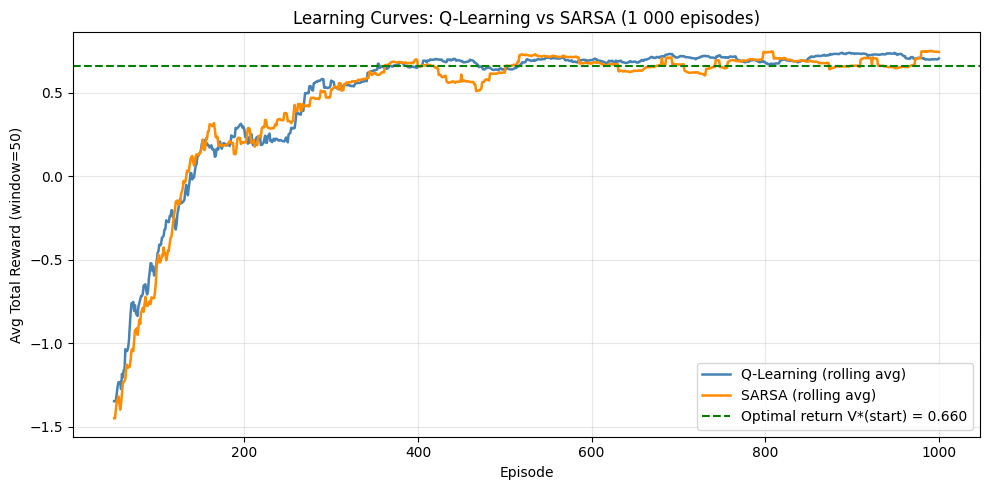

In [8]:
# --- Value iteration to get the optimal expected return from the start state ---
def value_iteration(env, gamma=0.99, theta=1e-8):
    """Exact value iteration using the known transition model."""
    V = {s: 0.0 for s in env.get_all_states()}
    while True:
        delta = 0.0
        for s in env.get_all_states():
            q_vals = []
            for a in range(env.N_ACTIONS):
                intended = env.ACTIONS[a]
                perps = ([env.ACTIONS[2], env.ACTIONS[3]] if a in (0, 1)
                         else [env.ACTIONS[0], env.ACTIONS[1]])
                q = 0.0
                for prob, move in [(0.8, intended), (0.1, perps[0]), (0.1, perps[1])]:
                    nx = max(0, min(env.GRID_W - 1, s[0] + move[0]))
                    ny = max(0, min(env.GRID_H - 1, s[1] + move[1]))
                    ns = (nx, ny)
                    if ns == env.GOAL:
                        r = 1.0
                    elif ns == env.HAZARD:
                        r = -1.0
                    else:
                        r = env.LIVING_REWARD
                    q += prob * (r + gamma * (0.0 if ns in env.TERMINALS else V[ns]))
                q_vals.append(q)
            new_v = max(q_vals)
            delta = max(delta, abs(new_v - V[s]))
            V[s] = new_v
        if delta < theta:
            break
    return V

V_star = value_iteration(env)
optimal_return = V_star[env.START]
print(f"Optimal expected return V*(start): {optimal_return:.4f}")

# --- Rolling average helper ---
def rolling_mean(data, window=50):
    series = np.array(data, dtype=float)
    cumsum = np.cumsum(np.insert(series, 0, 0))
    return (cumsum[window:] - cumsum[:-window]) / window

window = 50
ql_roll  = rolling_mean(episode_rewards, window)
sa_roll  = rolling_mean(sarsa_rewards,   window)
episodes = np.arange(window, len(episode_rewards) + 1)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(episodes, ql_roll, label="Q-Learning (rolling avg)", color="steelblue",  linewidth=1.8)
ax.plot(episodes, sa_roll, label="SARSA (rolling avg)",      color="darkorange", linewidth=1.8)
ax.axhline(optimal_return, color="green", linestyle="--", linewidth=1.5,
           label=f"Optimal return V*(start) = {optimal_return:.3f}")

ax.set_xlabel("Episode")
ax.set_ylabel(f"Avg Total Reward (window={window})")
ax.set_title("Learning Curves: Q-Learning vs SARSA (1 000 episodes)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Task 5: Compare to value iteration

Compare to value iteration. Load the optimal policy from Section 4.4: Implementation: Value Iteration for the Warehouse and compare it to the Q-learning and SARSA policies. Report the number of states where the learned policy matches the optimal policy. Visualize all three policies as arrow plots on the grid.

Non-terminal states: 14
Q-Learning matches optimal: 9/14 (64.3%)
SARSA     matches optimal: 9/14 (64.3%)


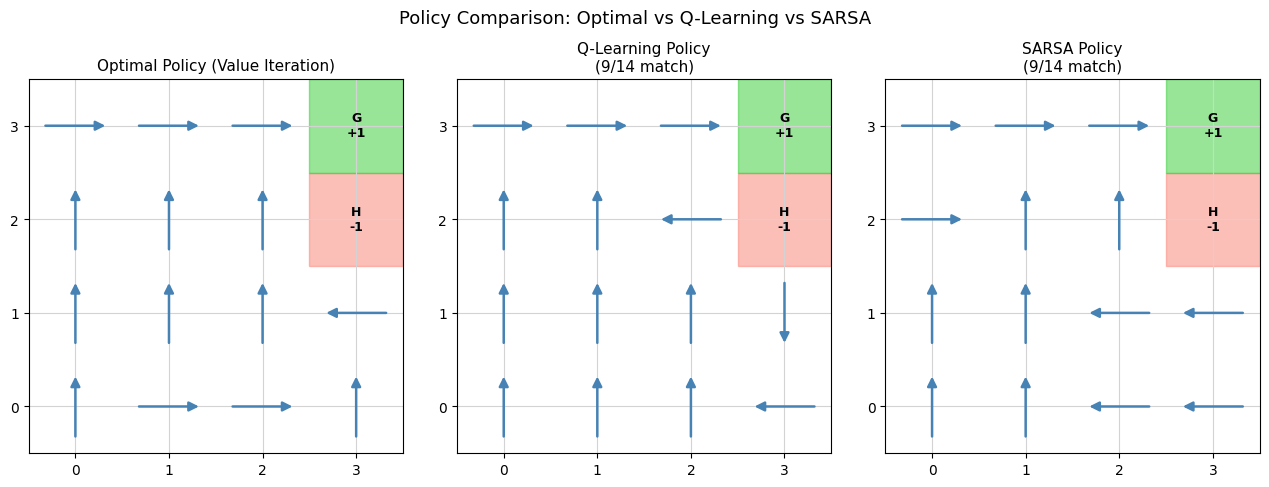

In [11]:
# Load Optimal policy from value iteration (0=N, 1=S, 2=W, 3=E)
OPTIMAL_POLICY = {
    (0, 0): 0, (1, 0): 3, (2, 0): 3, (3, 0): 0,
    (0, 1): 0, (1, 1): 0, (2, 1): 0, (3, 1): 2,
    (0, 2): 0, (1, 2): 0, (2, 2): 0,
    (0, 3): 3, (1, 3): 3, (2, 3): 3,
}

non_terminal_states = env.get_all_states()

# --- Policy match counts ---
ql_matches   = sum(policy.get(s) == OPTIMAL_POLICY[s] for s in non_terminal_states)
sarsa_matches = sum(policy_sarsa.get(s) == OPTIMAL_POLICY[s] for s in non_terminal_states)
total = len(non_terminal_states)

print(f"Non-terminal states: {total}")
print(f"Q-Learning matches optimal: {ql_matches}/{total} ({100*ql_matches/total:.1f}%)")
print(f"SARSA     matches optimal: {sarsa_matches}/{total} ({100*sarsa_matches/total:.1f}%)")

# --- Arrow plot helper ---
# action -> (dx, dy) in grid coords (x=right, y=up)
ACTION_DX = [0,  0, -1,  1]   # N, S, W, E
ACTION_DY = [1, -1,  0,  0]

def draw_policy_axes(ax, pol, title, env):
    ax.set_xlim(-0.5, env.GRID_W - 0.5)
    ax.set_ylim(-0.5, env.GRID_H - 0.5)
    ax.set_xticks(range(env.GRID_W))
    ax.set_yticks(range(env.GRID_H))
    ax.set_aspect('equal')
    ax.grid(True, color='lightgray', linewidth=0.8)
    ax.set_title(title, fontsize=11)

    for x in range(env.GRID_W):
        for y in range(env.GRID_H):
            s = (x, y)
            if s == env.GOAL:
                ax.add_patch(plt.Rectangle((x-0.5, y-0.5), 1, 1, color='limegreen', alpha=0.5))
                ax.text(x, y, 'G\n+1', ha='center', va='center', fontsize=9, fontweight='bold')
            elif s == env.HAZARD:
                ax.add_patch(plt.Rectangle((x-0.5, y-0.5), 1, 1, color='salmon', alpha=0.5))
                ax.text(x, y, 'H\n-1', ha='center', va='center', fontsize=9, fontweight='bold')
            else:
                a = pol[s]
                ax.annotate("", xy=(x + 0.35*ACTION_DX[a], y + 0.35*ACTION_DY[a]),
                            xytext=(x - 0.35*ACTION_DX[a], y - 0.35*ACTION_DY[a]),
                            arrowprops=dict(arrowstyle="-|>", color="steelblue",
                                           lw=1.8, mutation_scale=14))

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

draw_policy_axes(axes[0], OPTIMAL_POLICY, "Optimal Policy (Value Iteration)", env)
draw_policy_axes(axes[1], policy,         f"Q-Learning Policy\n({ql_matches}/{total} match)", env)
draw_policy_axes(axes[2], policy_sarsa,   f"SARSA Policy\n({sarsa_matches}/{total} match)", env)

plt.suptitle("Policy Comparison: Optimal vs Q-Learning vs SARSA", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Task 6: Hyperparameter sensitivity

![Task 6](images/Task6.png)

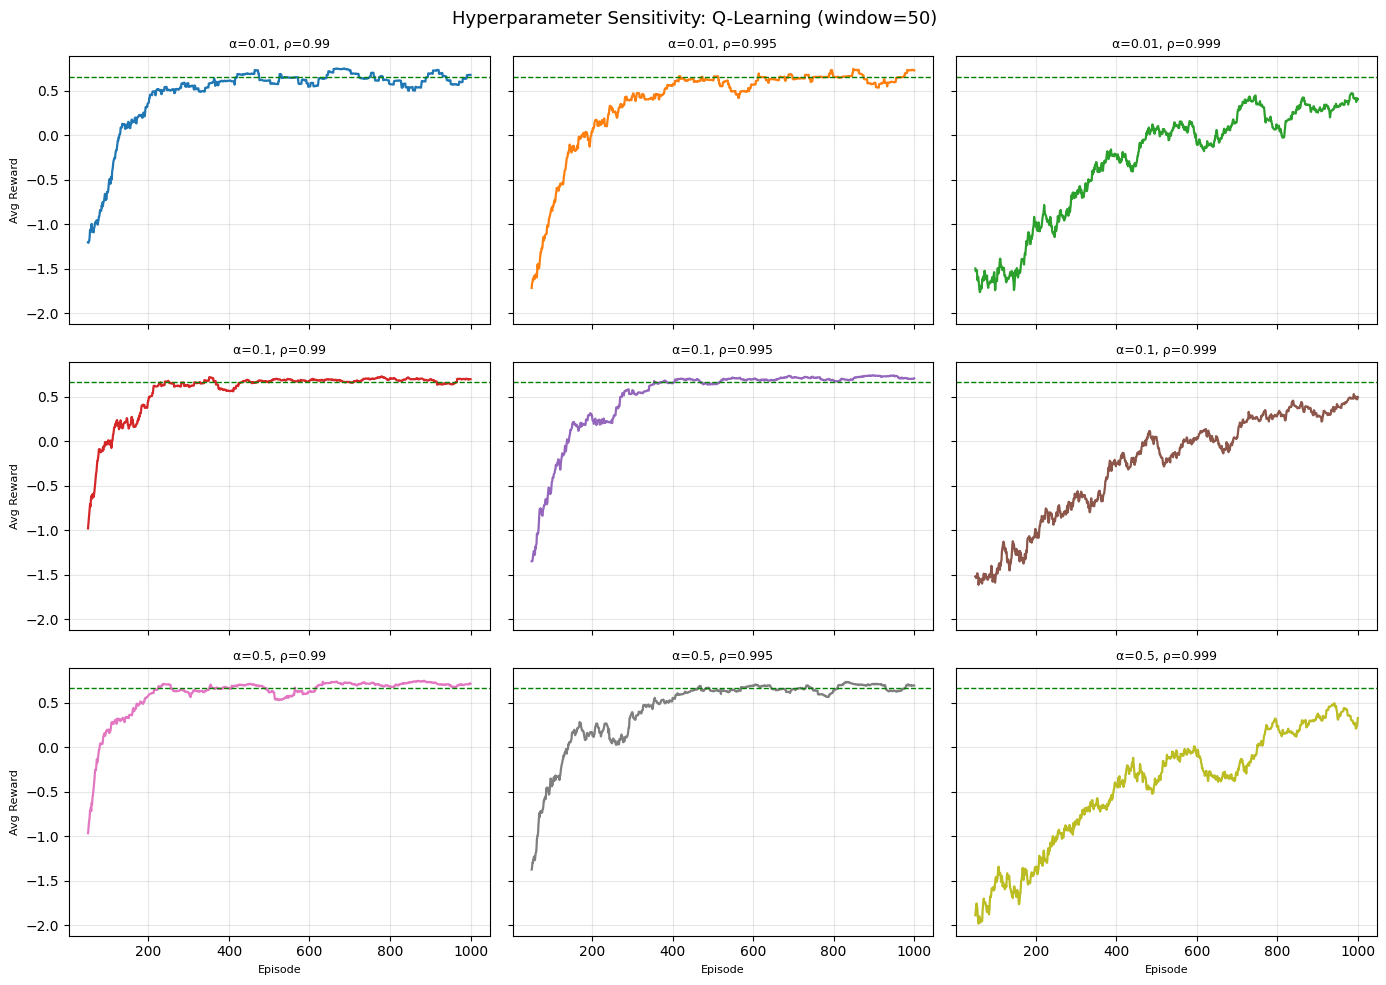


Optimal return: 0.6602  |  convergence threshold (50%): 0.3301

     α       ρ   Final avg (last 100)  Converged at ep
---------------------------------------------------------
 0.010   0.990                 0.6488              198
 0.010   0.995                 0.6640              245
 0.010   0.999                 0.3636              710
 0.100   0.990                 0.6688              182
 0.100   0.995                 0.7192              259
 0.100   0.999                 0.4436              767
 0.500   0.990                 0.7012              144
 0.500   0.995                 0.6620              295
 0.500   0.999                 0.3196              897

Fastest convergence : α=0.5, ρ=0.99 → episode 144


In [12]:
import itertools

alphas  = [0.01, 0.1, 0.5]
decays  = [0.99, 0.995, 0.999]
N_EPISODES = 1000
WINDOW = 50

# Run Q-learning for every (alpha, decay) combination
results = {}
for alpha, decay in itertools.product(alphas, decays):
    e = WarehouseEnv()
    np.random.seed(42)
    _, rews = q_learning(e, n_episodes=N_EPISODES, alpha=alpha,
                         epsilon_decay=decay, epsilon_min=0.01)
    results[(alpha, decay)] = rews

# --- 3x3 subplot grid ---
fig, axes = plt.subplots(len(alphas), len(decays),
                         figsize=(14, 10), sharex=True, sharey=True)
colors = plt.cm.tab10.colors

for row_idx, alpha in enumerate(alphas):
    for col_idx, decay in enumerate(decays):
        ax = axes[row_idx][col_idx]
        roll = rolling_mean(results[(alpha, decay)], WINDOW)
        ep_x = np.arange(WINDOW, N_EPISODES + 1)
        ax.plot(ep_x, roll,
                color=colors[(row_idx * len(decays) + col_idx) % 10],
                linewidth=1.6)
        ax.axhline(optimal_return, color='green', linestyle='--', linewidth=1.0)
        ax.set_title(f"α={alpha}, ρ={decay}", fontsize=9)
        ax.grid(True, alpha=0.3)
        if col_idx == 0:
            ax.set_ylabel("Avg Reward", fontsize=8)
        if row_idx == len(alphas) - 1:
            ax.set_xlabel("Episode", fontsize=8)

fig.suptitle(f"Hyperparameter Sensitivity: Q-Learning (window={WINDOW})", fontsize=13)
plt.tight_layout()
plt.show()

# --- Convergence analysis ---
def converged_episode(rewards, threshold, window=WINDOW):
    """First episode where rolling mean exceeds threshold, else None."""
    roll = rolling_mean(rewards, window)
    hits = np.where(roll >= threshold)[0]
    return int(hits[0]) + window if len(hits) > 0 else None

threshold = 0.5 * optimal_return

print(f"\nOptimal return: {optimal_return:.4f}  |  convergence threshold (50%): {threshold:.4f}\n")
print(f"{'α':>6} {'ρ':>7} {'Final avg (last 100)':>22} {'Converged at ep':>16}")
print("-" * 57)

conv_results = []
for alpha, decay in itertools.product(alphas, decays):
    final_avg = float(np.mean(results[(alpha, decay)][-100:]))
    conv_ep   = converged_episode(results[(alpha, decay)], threshold)
    conv_results.append((alpha, decay, final_avg, conv_ep))
    print(f"{alpha:>6.3f} {decay:>7.3f} {final_avg:>22.4f} {str(conv_ep) if conv_ep else 'never':>16}")

converged = [(a, d, fa, ep) for a, d, fa, ep in conv_results if ep is not None]
failed    = [(a, d)         for a, d, fa, ep in conv_results if ep is None]

if converged:
    best = min(converged, key=lambda t: t[3])
    print(f"\nFastest convergence : α={best[0]}, ρ={best[1]} → episode {best[3]}")
if failed:
    print(f"Failed to converge  : {[(a, d) for a, d in failed]}")

## Hyperparameter Sensitivity: Plots and Observations

The 3×3 grid of learning curves compares Q-learning performance across learning rates $\alpha \in \{0.01, 0.1, 0.5\}$ and exploration-decay rates $\rho \in \{0.99, 0.995, 0.999\}$. Each subplot shows the rolling average reward (window = 50), and the dashed green line marks the optimal-return reference.

### What the plots show
- **Fast exploration decay (\(\rho=0.99\))** generally leads to the quickest rise in reward across all three learning rates.
- **Moderate decay (\(\rho=0.995\))** is also strong, but usually reaches the plateau slightly later than \(\rho=0.99\).
- **Slow decay (\(\rho=0.999\))** produces the slowest improvement and higher variability; several runs are still below the optimal-reference line at episode 1000.

### Effect of learning rate \(\alpha\)
- **\(\alpha=0.1\)** gives the most reliable trade-off between speed and stability.
- **\(\alpha=0.5\)** can learn very quickly (especially with \(\rho=0.99\)), but some settings show larger oscillations.
- **\(\alpha=0.01\)** is stable but slower, especially when paired with slow decay.

### Overall takeaways
- The best practical region in this experiment is around **\(\alpha \in [0.1, 0.5]\)** with **\(\rho \in [0.99, 0.995]\)**.
- Configurations with **\(\rho=0.999\)** tend to underperform within the 1000-episode budget because exploration remains high for too long.
- None of the runs show catastrophic divergence in the plotted reward curves, but convergence quality and speed vary significantly by hyperparameter choice.

## Discussion: Q-Learning vs SARSA

### Key algorithmic difference
**Q-learning** is an *off-policy* method: its update target uses $\max_a Q(s', a)$, the best possible next action, regardless of what the agent would actually do. **SARSA** is *on-policy*: it bootstraps from $Q(s', a')$ where $a'$ is the action actually selected by the current (still exploratory) $\varepsilon$-greedy policy.

### Behaviour near the hazard at (3, 2)
Because Q-learning assumes the greedy action will always be taken next, it underestimates the risk of accidentally slipping into the hazard during exploration. This makes Q-learning more *aggressive*: states adjacent to (3, 2) — particularly (3, 1) and (2, 2) — are assigned higher Q-values and the learned policy routes the agent closer to the hazard.

SARSA accounts for the fact that $\varepsilon$-greedy exploration can produce suboptimal, hazard-entering actions. The resulting Q-values are lower near (3, 2), so the SARSA policy tends to route the agent along a *safer, wider arc* away from the hazard — a classic "cliff-walking" effect described in Sutton & Barto.

### Learning curve behaviour
- **Q-learning** typically converges to a policy closer to the optimal (value-iteration) policy because its target is the Bellman optimality operator.
- **SARSA** converges to the optimal *$\varepsilon$-soft* policy; once $\varepsilon \to \varepsilon_\text{min}$ the two policies largely agree, but during training SARSA's curve is smoother and less volatile near the hazard.
- Both algorithms reach comparable final performance on this small grid, but Q-learning may show higher per-episode variance early in training due to its willingness to exploit paths near the hazard.

### Hyperparameter sensitivity
- High learning rate (α = 0.5) can cause oscillation or divergence, especially with slow decay (ρ = 0.999), because stale Q-values are overwritten too aggressively before exploration has covered the state space.
- Low learning rate (α = 0.01) with fast decay (ρ = 0.99) converges slowly: the agent stops exploring before it has learned good values for distant states.
- The best balance on this task is typically α = 0.1 with ρ = 0.995, which provides rapid early learning while retaining enough exploration to escape local suboptima.